In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure file paths

# Human TF promoter-level chec-seq binding signal
chec_sumprom_pattern = "sumproms/*.gz"

# Yeast promoter-level chec-seq binding signal (see manuscript for source)
native_tf_sumprom_pattern = "../Yeast_Native_TF_outfiles/results/sumproms/*.gz"

# Promoter-level OPN score (see manuscript)
opn_scores_path = "metadata/comp_gp.csv"

## Imports

In [3]:
import glob

import matplotlib.colors as colors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import zscore

## Analysis settings

In [4]:
z_cutoff = 3

## Family definitions

In [5]:
FOXK1_WT = ["FOXP3", "FOXA2", "FOXF1", "FOXL1", "FOXL2", "FOXJ2", "FOXO3", "FOXP1", "FOXP2"]
GABPA_WT = ["ELF1", "ELF2", "ERF1", "ELK1", "ELK4", "ERG", "FLI1"]
SOX10_WT = ["SOX15", "SOX17", "SOX7", "SOX11", "SOX4", "SOX6", "SOX30", "SOX9", "SOX13", "SOX5"]
HXD10_WT = ["CDX2", "HOXA11", "HOXC10", "HOXD9", "HOXA10", "HOXC9", "HOXA9", "HOXB9", "CDX4", "HOXC13"]
GATA1_WT = ["GATA3", "GATA6", "GATA4", "GATA2", "GATA5"]
BATF3_WT = ["ATF4", "FOS", "CREB5", "ATF1", "CREB1", "ATF2"]
HEY1_WT = ["MNT", "MLXIPL", "MLX", "MXD4"]
NFAC4_WT = ["NFATC4", "NFATC3"]
TF2LY_WT = ["TGIF2LX", "TGIF2LY", "TGIF1", "TGIF2"]
PO3F2_WT = ["POU2F3", "POU3F4", "POU3F1"]

dbd_fam_dict = {
    "FOXK1": FOXK1_WT,
    "GABPA": GABPA_WT,
    "SOX10": SOX10_WT,
    "HXD10": HXD10_WT,
    "GATA1": GATA1_WT,
    "BATF3": BATF3_WT,
    "HEY1": HEY1_WT,
    "NFAC4": NFAC4_WT,
    "TF2LY": TF2LY_WT,
    "PO3F2": PO3F2_WT,
}

family_name = {
    "BATF3": "bZIP",
    "FOXK1": "Forkhead",
    "GABPA": "ETS",
    "HEY1": "bHLH",
    "HXD10": "Homeodomain\nHOX",
    "NFAC4": "Rel",
    "SOX10": "SOX",
    "TF2LY": "Homeodomain\nTALE-Type",
    "PO3F2": "Homeodomain\nPOU",
    "GATA1": "GATA",
}

exists_in_yeast = {
    "FOXK1": "yes",
    "GABPA": "no",
    "SOX10": "no",
    "HXD10": "no",
    "GATA1": "yes",
    "BATF3": "yes",
    "HEY1": "yes",
    "NFAC4": "no",
    "TF2LY": "no",
    "PO3F2": "no",
}

fam_plot_order = ["FOXK1", "BATF3", "GATA1", "HEY1", "GABPA", "NFAC4", "TF2LY", "PO3F2", "PO3F2", "HXD10", "SOX10"]

## Helper functions

In [6]:
# Keep only reproducible replicate profiles before averaging by TF
def filter_reproducible(sumprom_all: pd.DataFrame, cutoff):
    df = sumprom_all.copy()
    groups = pd.Series(df.columns, index=df.columns).str.rsplit("_", n=2).str[0]

    keep = []
    for _, members in groups.groupby(groups).groups.items():
        if len(members) < 2:
            continue
        corr = df[members].corr()
        np.fill_diagonal(corr.values, np.nan)
        max_corrs = corr.max(axis=1)
        reproducible = max_corrs[max_corrs >= cutoff].index.tolist()
        keep.extend(reproducible)
    return df[keep]


# Build y positions with extra spacing between families
def spaced_positions(fams, tf_spacing=1.1, fam_gap=1.0):
    xpos, seps, x = [], [], 0.0
    prev = None
    for fam in fams:
        if prev is not None and fam != prev:
            seps.append(x - 0.5 + fam_gap / 2)
            x += fam_gap
        xpos.append(x)
        x += tf_spacing
        prev = fam
    return np.array(xpos), seps


# Trim a colormap to the softer range used in the heatmap
def truncate_cmap(cmap, minval=0.1, maxval=0.9, n=256):
    return LinearSegmentedColormap.from_list(
        f"trunc({cmap.name},{minval:.2f},{maxval:.2f})",
        cmap(np.linspace(minval, maxval, n))
    )


# Order TFs and promoters
def compute_orders_family(sumprom_z, tfs, yeast_zero, z):
    # promoters bound by each TF (z > cutoff)
    bound_sets = {tf: set(sumprom_z.index[(sumprom_z[tf] > z)]) for tf in tfs}

    # subset of bound promoters that are yeast-unbound ("new")
    new_sets = {tf: set(sumprom_z.index[(sumprom_z[tf] > z) & yeast_zero]) for tf in tfs}

    # counts per TF
    n_bound_per_tf = {tf: len(bound_sets[tf]) for tf in tfs}
    n_new_per_tf = {tf: len(new_sets[tf]) for tf in tfs}

    # fraction of new promoters among bound promoters
    frac_new_per_tf = {
        tf: (n_new_per_tf[tf] / n_bound_per_tf[tf]) if n_bound_per_tf[tf] > 0 else 0.0
        for tf in tfs
    }

    # sort TFs by this fraction (descending), then by name
    tfs_sorted = sorted(tfs, key=lambda tf: (-frac_new_per_tf[tf], tf))

    # promoters bound by all TFs (first block)
    all_bound_mask = ((sumprom_z[tfs_sorted] > z).all(axis=1)) & yeast_zero
    shared_all = list(sumprom_z.index[all_bound_mask])

    # sort by strongest signal across TFs
    shared_all_sorted = sorted(
        shared_all,
        key=lambda p: float(sumprom_z.loc[p, tfs_sorted].max()),
        reverse=True
    )

    # add TF-specific promoter blocks (avoiding duplicates)
    used = set(shared_all_sorted)
    blocks = []
    for tf in tfs_sorted:
        candidates = list(new_sets[tf] - used)

        # sort by this TF's binding strength
        candidates_sorted = sorted(
            candidates,
            key=lambda p: float(sumprom_z.loc[p, tf]),
            reverse=True
        )

        blocks.extend(candidates_sorted)
        used.update(candidates_sorted)

    # final promoter order
    prom_order = shared_all_sorted + blocks

    return tfs_sorted, prom_order, n_new_per_tf, n_bound_per_tf, frac_new_per_tf

## Data loading

In [7]:
# Load and combine the human TF promoter signal matrices
sumprom_chec_files = glob.glob(chec_sumprom_pattern)
sumprom_all = pd.concat([pd.read_parquet(x) for x in sumprom_chec_files], axis=1)

# Keep reproducible replicates and remove the same excluded samples
corr_cutoff = 0.895
sumprom_filtered = filter_reproducible(sumprom_all, cutoff=corr_cutoff)
cols = sumprom_filtered.columns.astype(str)
base_sumprom = cols.str.rsplit("_", n=2).str[0]
cols_to_keep = set(sum(dbd_fam_dict.values(), []))

sumprom = sumprom_filtered.T.groupby(base_sumprom).mean().T
sumprom = sumprom.loc[:, sumprom.columns.intersection(cols_to_keep)]
sumprom_z = sumprom.apply(zscore)

# Load the yeast native TF matrix
native_tf_sumprom_files = glob.glob(native_tf_sumprom_pattern)
native_tf_sumprom = pd.concat([pd.read_parquet(x) for x in native_tf_sumprom_files], axis=1)
non_transcription_factors = ["Nfi1", "Itc1", "Gal11", "Nhp6A", "Spt20", "Nhp6B", "Abf2", "Tog1", "Siz1", "Cyc8", "Mss11"]
native_tf_sumprom = native_tf_sumprom.drop(columns=non_transcription_factors)
native_tf_sumprom_z = native_tf_sumprom.apply(zscore)

# Load OPN scores for the heatmap figure
opn_scores_unfiltered = pd.read_csv(opn_scores_path, index_col="name").iloc[:, 1:]
opn_scores = opn_scores_unfiltered[opn_scores_unfiltered.index.isin(sumprom_z.index)]

## Plot


Per-TF yeast-binding distribution (% of human-bound promoters):
        ATF1 | ≥3:  34.09 | 2:   4.55 | 1:  13.64 | 0:  47.73
        ATF2 | ≥3:  61.17 | 2:   3.88 | 1:  12.62 | 0:  22.33
        CDX2 | ≥3:  76.92 | 2:   5.77 | 1:   6.73 | 0:  10.58
        CDX4 | ≥3:  83.33 | 2:   1.28 | 1:   7.69 | 0:   7.69
       CREB1 | ≥3:  70.83 | 2:   0.00 | 1:   8.33 | 0:  20.83
        ELF1 | ≥3:  69.74 | 2:   9.21 | 1:   2.63 | 0:  18.42
        ELF2 | ≥3:  53.73 | 2:   7.46 | 1:   5.97 | 0:  32.84
        ELK1 | ≥3:  57.58 | 2:   6.06 | 1:  12.12 | 0:  24.24
        ELK4 | ≥3:  54.55 | 2:  13.64 | 1:   4.55 | 0:  27.27
        ERF1 | ≥3:  70.33 | 2:   6.59 | 1:   8.79 | 0:  14.29
         ERG | ≥3:  75.41 | 2:   6.56 | 1:   4.92 | 0:  13.11
        FLI1 | ≥3:  71.79 | 2:   8.97 | 1:   8.97 | 0:  10.26
       FOXA2 | ≥3:  61.04 | 2:   6.49 | 1:  11.69 | 0:  20.78
       FOXF1 | ≥3:  70.83 | 2:  20.83 | 1:   8.33 | 0:   0.00
       FOXJ2 | ≥3:  72.73 | 2:  12.12 | 1:  10.10 | 0:   5.05
     

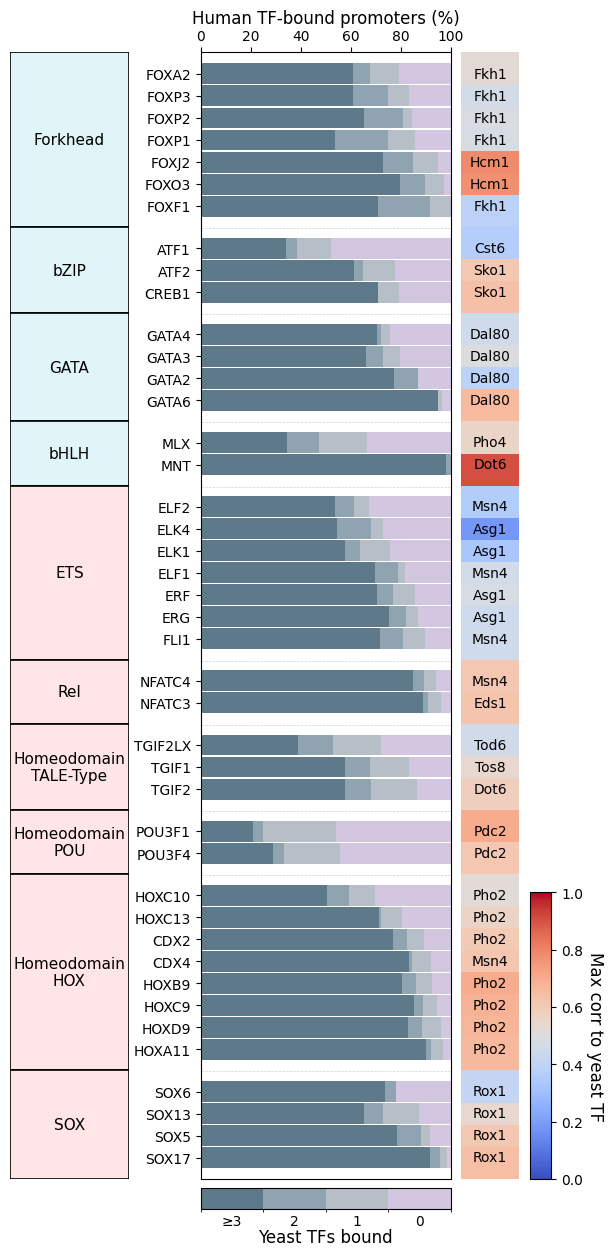

In [8]:
# Plot the stacked yeast-binding distribution for each human TF
def plot_yeast_binding_distribution(
    sumprom_z,
    native_tf_sumprom_z,
    dbd_fam_dict,
    fam_plot_order,
    exists_in_yeast,
    family_name,
    z_cutoff
):
    z_cutoff = z_cutoff
    tf_spacing = 1.1
    fam_gap = 1.0

    col_ge3 = "#5E7A8A"
    col_eq2 = "#8FA3B1"
    col_eq1 = "#B6BEC8"
    col_eq0 = "#D2C6E0"

    # Align the yeast matrix to the human promoter index
    native = native_tf_sumprom_z.reindex(sumprom_z.index)
    yeast_count = (native > z_cutoff).sum(axis=1).astype(int)

    # Compute the fraction of human-bound promoters in each yeast-count bin
    tfs = list(sumprom_z.columns)

    pct_ge3_all = pd.Series(index=tfs, dtype=float)
    pct_eq2_all = pd.Series(index=tfs, dtype=float)
    pct_eq1_all = pd.Series(index=tfs, dtype=float)
    pct_eq0_all = pd.Series(index=tfs, dtype=float)

    for tf in tfs:
        human_bound = sumprom_z[tf] > z_cutoff
        n = int(human_bound.sum())
        if n == 0:
            pct_ge3_all[tf] = np.nan
            pct_eq2_all[tf] = np.nan
            pct_eq1_all[tf] = np.nan
            pct_eq0_all[tf] = np.nan
            continue
        yc = yeast_count[human_bound]
        pct_ge3_all[tf] = 100.0 * (yc >= 3).mean()
        pct_eq2_all[tf] = 100.0 * (yc == 2).mean()
        pct_eq1_all[tf] = 100.0 * (yc == 1).mean()
        pct_eq0_all[tf] = 100.0 * (yc == 0).mean()

    # Order TFs by family and then by the fraction with zero yeast TFs
    tf_to_fam = {tf: fam for fam, lst in dbd_fam_dict.items() for tf in lst}
    fam_of = [tf_to_fam.get(tf, "Other") for tf in tfs]
    order = pd.DataFrame({"tf": tfs, "fam": fam_of})

    fam_rank = {fam: i for i, fam in enumerate(fam_plot_order)}
    other_rank = len(fam_plot_order) + 1
    order["fam_rank"] = order["fam"].map(lambda f: fam_rank.get(f, other_rank))
    order["pct_zero"] = order["tf"].map(pct_eq0_all)

    order = order.sort_values(
        ["fam_rank", "fam", "pct_zero", "tf"],
        ascending=[True, True, False, True]
    ).reset_index(drop=True)

    cols_ordered = order["tf"].tolist()
    fam_ordered = order["fam"].tolist()
    xpos, separators = spaced_positions(fam_ordered, tf_spacing=tf_spacing, fam_gap=fam_gap)

    pct_ge3 = pct_ge3_all[cols_ordered].to_numpy(float)
    pct_eq2 = pct_eq2_all[cols_ordered].to_numpy(float)
    pct_eq1 = pct_eq1_all[cols_ordered].to_numpy(float)
    pct_eq0 = pct_eq0_all[cols_ordered].to_numpy(float)

    print("\nPer-TF yeast-binding distribution (% of human-bound promoters):")
    for tf in tfs:
        print(
            f"{tf:>12s} | "
            f"≥3: {pct_ge3_all[tf]:6.2f} | "
            f"2: {pct_eq2_all[tf]:6.2f} | "
            f"1: {pct_eq1_all[tf]:6.2f} | "
            f"0: {pct_eq0_all[tf]:6.2f}"
        )

    fig, ax = plt.subplots(figsize=(3.6, 12))

    bar_h = tf_spacing * 0.95
    for y, p3, p2, p1, p0 in zip(xpos, pct_ge3, pct_eq2, pct_eq1, pct_eq0):
        if np.isnan(p3) or np.isnan(p0):
            continue
        left = 0.0
        ax.barh(y, p3, left=left, height=bar_h, color=col_ge3, edgecolor="none")
        left += p3
        ax.barh(y, p2, left=left, height=bar_h, color=col_eq2, edgecolor="none")
        left += p2
        ax.barh(y, p1, left=left, height=bar_h, color=col_eq1, edgecolor="none")
        left += p1
        ax.barh(y, p0, left=left, height=bar_h, color=col_eq0, edgecolor="none")

    for sy in separators:
        ax.axhline(sy, linestyle="--", linewidth=0.5, color="0.7", alpha=0.6)

    ax.set_yticks(xpos)
    ax.set_yticklabels(["ERF" if tf == "ERF1" else tf for tf in cols_ordered])
    ax.tick_params(axis="y", labelsize=10)

    ax.set_xlim(0, 100)
    ax.set_xlabel("Human TF-bound promoters (%)", fontsize=12)
    ax.xaxis.set_label_position("top")
    ax.xaxis.tick_top()

    plt.margins(y=0.01)
    ax.invert_yaxis()

    plt.tight_layout()
    fig.canvas.draw()

    # Add the family strip on the left
    yeast_no_color, yeast_yes_color = "#FFE5E5", "#DFF5F7"

    blocks = []
    start = 0
    for i in range(1, len(fam_ordered) + 1):
        if i == len(fam_ordered) or fam_ordered[i] != fam_ordered[i - 1]:
            blocks.append((fam_ordered[start], start, i - 1))
            start = i

    pos = ax.get_position()
    strip_w = 0.33
    pad = 0.20

    ax_fam = fig.add_axes([pos.x0 - pad - strip_w, pos.y0, strip_w, pos.height], sharey=ax)
    ax_fam.set_xlim(0, 1)
    ax_fam.axis("off")

    n = len(xpos)
    edges = np.empty(n + 1, dtype=float)
    edges[1:-1] = 0.5 * (xpos[:-1] + xpos[1:])

    y0_lim, y1_lim = ax.get_ylim()
    ymin_lim, ymax_lim = min(y0_lim, y1_lim), max(y0_lim, y1_lim)
    edges[0] = ymin_lim
    edges[-1] = ymax_lim

    for fam, s0, e0 in blocks:
        y0 = edges[s0]
        y1 = edges[e0 + 1]
        y_lo, y_hi = min(y0, y1), max(y0, y1)

        flag = str(exists_in_yeast.get(fam, "no")).strip().lower()
        fc = yeast_yes_color if flag == "yes" else yeast_no_color

        ax_fam.add_patch(
            mpatches.Rectangle((0, y_lo), 1, y_hi - y_lo, fc=fc, ec="black", lw=1.2)
        )

        label = family_name.get(fam, fam)
        yc = 0.5 * (y_lo + y_hi)
        ax_fam.text(0.5, yc, label, ha="center", va="center", fontsize=11)

    # Add the discrete colorbar for the stacked bars
    bar_cmap = colors.ListedColormap([col_ge3, col_eq2, col_eq1, col_eq0])
    bar_norm = colors.BoundaryNorm([0, 1, 2, 3, 4], bar_cmap.N)
    bar_sm = cm.ScalarMappable(norm=bar_norm, cmap=bar_cmap)
    bar_sm.set_array([])

    pos = ax.get_position()
    cb_h = 0.018
    cb_pad = 0.025
    cb_ax = fig.add_axes([pos.x0, pos.y0 - cb_pad, pos.width, cb_h])
    cb = fig.colorbar(bar_sm, cax=cb_ax, orientation="horizontal", ticks=[0.5, 1.5, 2.5, 3.5])
    cb.ax.set_xticklabels(["≥3", "2", "1", "0"])
    cb.ax.tick_params(length=0)
    cb.set_label("Yeast TFs bound", fontsize=12, labelpad=0)

    # Add the right-side strip with the maximum yeast TF correlation
    native_for_corr = native_tf_sumprom_z.reindex(sumprom_z.index)

    max_corr_vals = []
    max_corr_names = []
    for tf in cols_ordered:
        x = sumprom_z[tf]
        corrs = native_for_corr.corrwith(x)
        best_name = corrs.idxmax()
        best_val = corrs.loc[best_name]
        max_corr_vals.append(best_val)
        max_corr_names.append(best_name)
        print(f"{tf:>12s} | best yeast TF: {best_name:>12s} | max corr: {best_val:5.3f}")

    max_corr_vals = np.asarray(max_corr_vals, float)

    fig.canvas.draw()
    pos = ax.get_position()

    hm_w = 0.16
    hm_pad = 0.03
    ax_corr = fig.add_axes([pos.x1 + hm_pad, pos.y0, hm_w, pos.height], sharey=ax)
    ax_corr.set_xlim(0, 1)
    ax_corr.set_xticks([])
    ax_corr.tick_params(axis="y", left=False, labelleft=False)
    for sp in ax_corr.spines.values():
        sp.set_visible(False)

    y_edges = np.empty(len(xpos) + 1, dtype=float)
    y_edges[1:-1] = 0.5 * (xpos[:-1] + xpos[1:])
    y0_lim, y1_lim = ax.get_ylim()
    ymin_lim, ymax_lim = min(y0_lim, y1_lim), max(y0_lim, y1_lim)
    y_edges[0] = ymin_lim
    y_edges[-1] = ymax_lim

    x_edges = np.array([0.0, 1.0])
    mat_corr = max_corr_vals[:, None]

    pcm = ax_corr.pcolormesh(
        x_edges,
        y_edges,
        mat_corr,
        cmap="coolwarm",
        vmin=0,
        vmax=1,
        shading="flat"
    )

    ytick_fs = ax.get_yticklabels()[0].get_fontsize() if ax.get_yticklabels() else 10
    for y, name in zip(xpos, max_corr_names):
        ax_corr.text(0.5, y, name, ha="center", va="center", fontsize=ytick_fs, clip_on=True)

    corr_cb_w = 0.06
    corr_cb_pad = 0.03
    cax_corr = fig.add_axes([pos.x1 + hm_pad + hm_w + corr_cb_pad, pos.y0, corr_cb_w, pos.height - 0.7])
    cb_corr = fig.colorbar(pcm, cax=cax_corr)
    cb_corr.set_label("Max corr to yeast TF", fontsize=12, rotation=270, labelpad=15)

    plt.show()

    return yeast_count


yeast_count = plot_yeast_binding_distribution(
    sumprom_z=sumprom_z,
    native_tf_sumprom_z=native_tf_sumprom_z,
    dbd_fam_dict=dbd_fam_dict,
    fam_plot_order=fam_plot_order,
    exists_in_yeast=exists_in_yeast,
    family_name=family_name,
    z_cutoff=z_cutoff
)

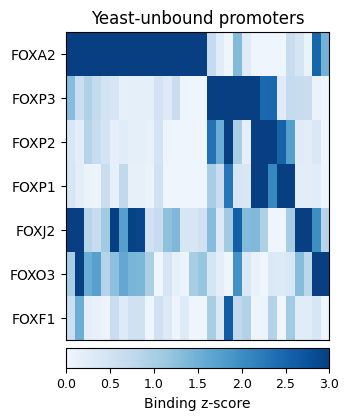

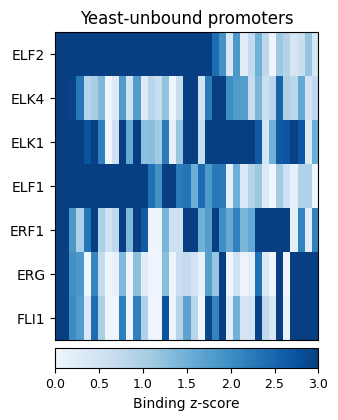

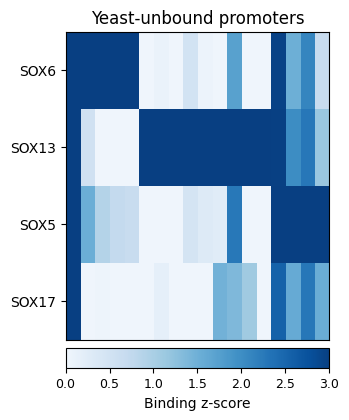

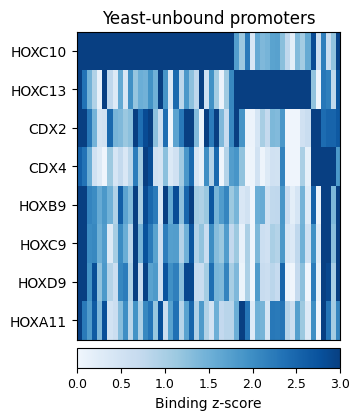

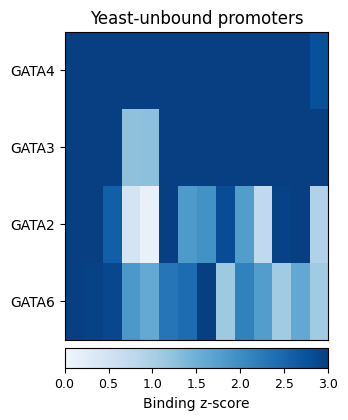

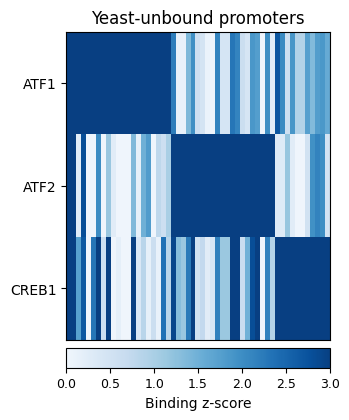

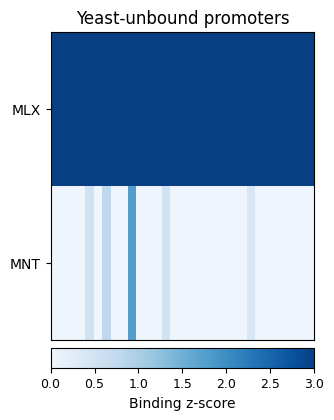

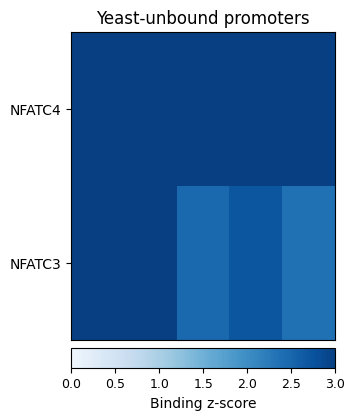

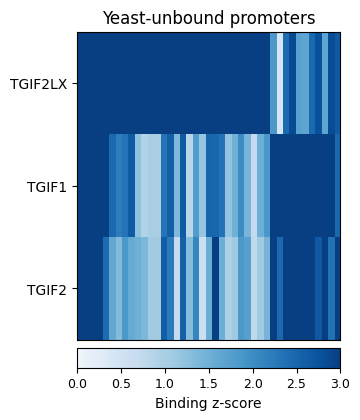

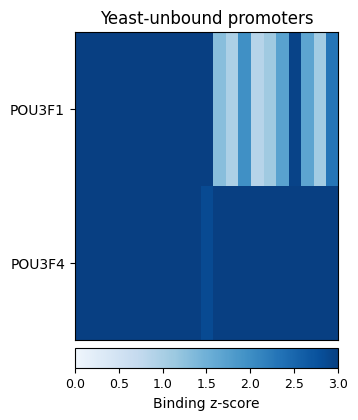

In [9]:
# Plot yeast-unbound promoter heatmaps for each family
def plot_yeast_unbound_family_heatmaps(
    sumprom_z,
    dbd_fam_dict,
    yeast_count,
    z_cutoff,
    opn_scores,
):
    z = z_cutoff
    yeast_zero = yeast_count == 0

    # Keep the original OPN scaling setup even though the strip is not plotted
    opn_all = opn_scores["opn_score"].astype(float)
    opn_min = float(opn_all.min())
    opn_max = float(opn_all.max())
    opn_med = float(opn_all.median())

    for fam, tfs in dbd_fam_dict.items():
        tfs = [tf for tf in tfs if tf in sumprom_z.columns]
        if len(tfs) == 0:
            continue

        tfs_sorted, prom_order, n_new_per_tf, n_bound_per_tf, frac_new_per_tf = compute_orders_family(
            sumprom_z=sumprom_z,
            tfs=tfs,
            yeast_zero=yeast_zero,
            z=z
        )
        if len(prom_order) == 0:
            continue

        # Build the TF x promoter matrix for the heatmap
        M = sumprom_z.loc[prom_order, tfs_sorted].T

        # Keep the OPN strip values and normalization unchanged
        opn_row = opn_scores.reindex(prom_order)["opn_score"].astype(float).to_numpy()[None, :]
        opn_norm = colors.TwoSlopeNorm(vmin=opn_min, vcenter=opn_med, vmax=opn_max)

        fig = plt.figure(figsize=(3.4, 4))
        ax = fig.add_subplot(1, 1, 1)

        ncols = M.shape[1]
        x0_data, x1_data = -0.5, float(ncols) - 0.5

        soft_coolwarm = truncate_cmap(plt.cm.Blues, 0.04, 0.94)

        im = ax.imshow(
            M.values,
            aspect="auto",
            interpolation="nearest",
            vmin=0,
            vmax=3,
            cmap=soft_coolwarm
        )
        ax.set_xlim(x0_data, x1_data)

        ax.set_xticks([])
        ax.set_xticklabels([])
        ax.tick_params(axis="x", bottom=False, labelbottom=False)

        ax.set_yticks(np.arange(M.shape[0]))
        ax.set_yticklabels(list(M.index), fontsize=10)

        ax.set_title("Yeast-unbound promoters")

        fig.canvas.draw()
        main_pos = ax.get_position()

        gap = 0.07
        cb_h = 0.05

        cax_bind = fig.add_axes([
            main_pos.x0,
            main_pos.y0 - gap,
            main_pos.width,
            cb_h
        ])

        cb_bind = fig.colorbar(im, cax=cax_bind, orientation="horizontal")
        cb_bind.set_label("Binding z-score", fontsize=10)
        cb_bind.ax.tick_params(labelsize=9)

        plt.show()


plot_yeast_unbound_family_heatmaps(
    sumprom_z=sumprom_z,
    dbd_fam_dict=dbd_fam_dict,
    yeast_count=yeast_count,
    z_cutoff=z_cutoff,
    opn_scores=opn_scores,
)

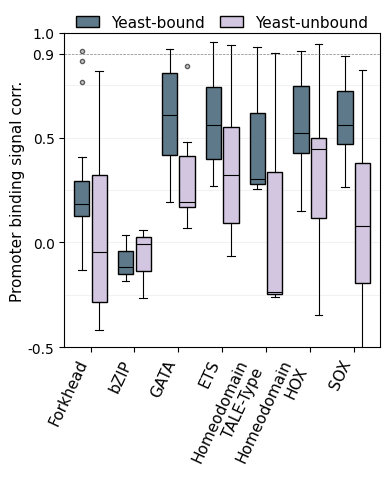

In [10]:
# Compare TF-family correlation distributions for yeast-bound and yeast-unbound promoters
def plot_family_correlation_boxplots(
    sumprom_z,
    dbd_fam_dict,
    fam_plot_order,
    family_name,
    yeast_count,
    z_cutoff,
):
    z = z_cutoff
    yeast_zero = yeast_count == 0
    yeast_bound3 = yeast_count >= 3

    vals_bound = []
    vals_unbound = []
    labels = []
    seen = set()

    for fam in fam_plot_order:
        if fam in seen:
            continue
        seen.add(fam)

        if fam not in dbd_fam_dict:
            continue
        tfs = [tf for tf in dbd_fam_dict[fam] if tf in sumprom_z.columns]
        if len(tfs) < 3:
            continue

        fam_any = (sumprom_z[tfs] > z).any(axis=1)
        prom_bound = sumprom_z.index[fam_any & yeast_bound3]
        prom_unbound = sumprom_z.index[fam_any & yeast_zero]

        if len(prom_bound) < 3 or len(prom_unbound) < 3:
            continue

        # Compute the upper-triangle pairwise correlations for one promoter set
        def pairwise_corr_values(promoters):
            df = sumprom_z.loc[promoters, tfs].astype(float).dropna(how="all")
            if df.shape[0] < 2:
                return np.array([])
            corr = df.corr(method="pearson").values
            iu = np.triu_indices_from(corr, k=1)
            v = corr[iu]
            return v[~np.isnan(v)]

        v_bound = pairwise_corr_values(prom_bound)
        v_unbound = pairwise_corr_values(prom_unbound)
        if v_bound.size == 0 or v_unbound.size == 0:
            continue

        vals_bound.append(v_bound)
        vals_unbound.append(v_unbound)
        labels.append(family_name.get(fam, fam))

    if len(labels) == 0:
        raise RuntimeError("No families pass the filters (need ≥3 TFs and ≥3 promoters per group).")

    n = len(labels)
    step = 2
    pos = np.arange(n) * step
    width = 0.7
    offset = 0.40

    fig, ax = plt.subplots(figsize=(4, 5))

    flierprops = dict(
        marker=".",
        markersize=6,
        markerfacecolor="darkgray",
        markeredgecolor="black",
        alpha=0.6
    )

    bp_bound = ax.boxplot(
        vals_bound,
        positions=pos - offset,
        widths=width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=True,
        flierprops=flierprops
    )
    bp_unbound = ax.boxplot(
        vals_unbound,
        positions=pos + offset,
        widths=width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=True,
        flierprops=flierprops
    )

    for patch in bp_bound["boxes"]:
        patch.set_facecolor("#5E7A8A")
        patch.set_edgecolor("black")
    for patch in bp_unbound["boxes"]:
        patch.set_facecolor("#D2C6E0")
        patch.set_edgecolor("black")

    for key in ("whiskers", "caps", "medians", "fliers"):
        for line in bp_bound.get(key, []):
            line.set_color("black")
            line.set_linewidth(0.8)
        for line in bp_unbound.get(key, []):
            line.set_color("black")
            line.set_linewidth(0.8)

    ax.axhline(y=0.9, ls="--", lw=0.5, color="0.3", alpha=0.7)
    yticks = [1.0, 0.9, 0.5, 0.0, -0.5]
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{y:.1f}" for y in yticks])

    ax.set_xticks(pos)
    ax.set_xticklabels(labels, rotation=65, ha="right", fontsize=11)
    ax.set_ylabel("Promoter binding signal corr.", fontsize=11, labelpad=2)
    ax.set_ylim(-0.5, 1)
    ax.set_xlim(pos[0] - step * 0.6, pos[-1] + step * 0.6)
    ax.set_axisbelow(True)

    ygrid = np.arange(-0.5, 1.01, 0.25)
    for y in ygrid:
        ax.axhline(y=y, color="black", linestyle="solid", linewidth=0.4, alpha=0.1, zorder=0)

    legend_handles = [
        mpatches.Patch(facecolor="#5E7A8A", edgecolor="black", label="Yeast-bound"),
        mpatches.Patch(facecolor="#D2C6E0", edgecolor="black", label="Yeast-unbound"),
    ]

    ax.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.1),
        ncol=2,
        frameon=False,
        fontsize=11,
        handlelength=1.5,
        labelspacing=0.5,
        columnspacing=1
    )

    plt.tight_layout()
    plt.show()


plot_family_correlation_boxplots(
    sumprom_z=sumprom_z,
    dbd_fam_dict=dbd_fam_dict,
    fam_plot_order=fam_plot_order,
    family_name=family_name,
    yeast_count=yeast_count,
    z_cutoff=z_cutoff,
)